# Classification using K-NN


## Prerequisites

Students require knowledge of following topics before starting this read:

1. Introduction to K-NN
2. Bias and Variance.


## Learning objectives

After reading this notebook, students must be able to:

1. Explain the working of K-NN classifiers.
2. Discuss about variation in K values and its effect.
3. Implement K-NN algorithm for classification.
4. Exemplify the application of K-NN in classification.


As discussed in the previous chapter, K-NN is a lazy learning algorithm used for classification and regression. In this notebook, you are learning about K-NN classifiers, effects of variation of $K$ in classifier along with application areas of K-NN classifiers.



## K-NN classifier

K-NN classifiers are K-NN based classification algorithm with a base of **majority voting** scheme. After setting the hyperparameters of the model, the algorithm of K-NN classifier follows as:


1. Training phase

  Provided the training dataset, $D = \{\{\mathbf{x}_i \in \mathbb{R}^m, y_i\}, i= 1, 2, \cdots, n\}$.
 
  - Store the training dataset in memory, either directly or using advanced data structures(like kd-tree,ball-tree).
  

2. Prediction phase

  Given a test sample $\mathbf{x}_t$,

  1. Compute its "K"-nearest neighbors set, $S_{\mathbf{x}_t}$.
    Note: K-nearest neighbors set is defined as, $S_{\mathbf{x}_t} \subseteq D$ such that:
    1. The cardinality of $S_{\mathbf{x}_t}$ , $\vert S_{\mathbf{x}_t}\vert = K$.
    2. All points of training set $D$ that is not in $S_{\mathbf{x}_t}$ is atleast as far away from $\mathbf{x}_t$ as the furthest point in $S_{\mathbf{x}_t}$. Mathematically, $\forall(\mathbf{x}',y') \in D \backslash S_{\mathbf{x}_t}$
    
    $$\text{dist}(\mathbf{x}_t, \mathbf{x}') \ge\max_{(\mathbf{x}'',y'')\in S_\mathbf{x}} \text{dist}(\mathbf{x}_t,\mathbf{x}'')$$
    
    <center>


<p><img src="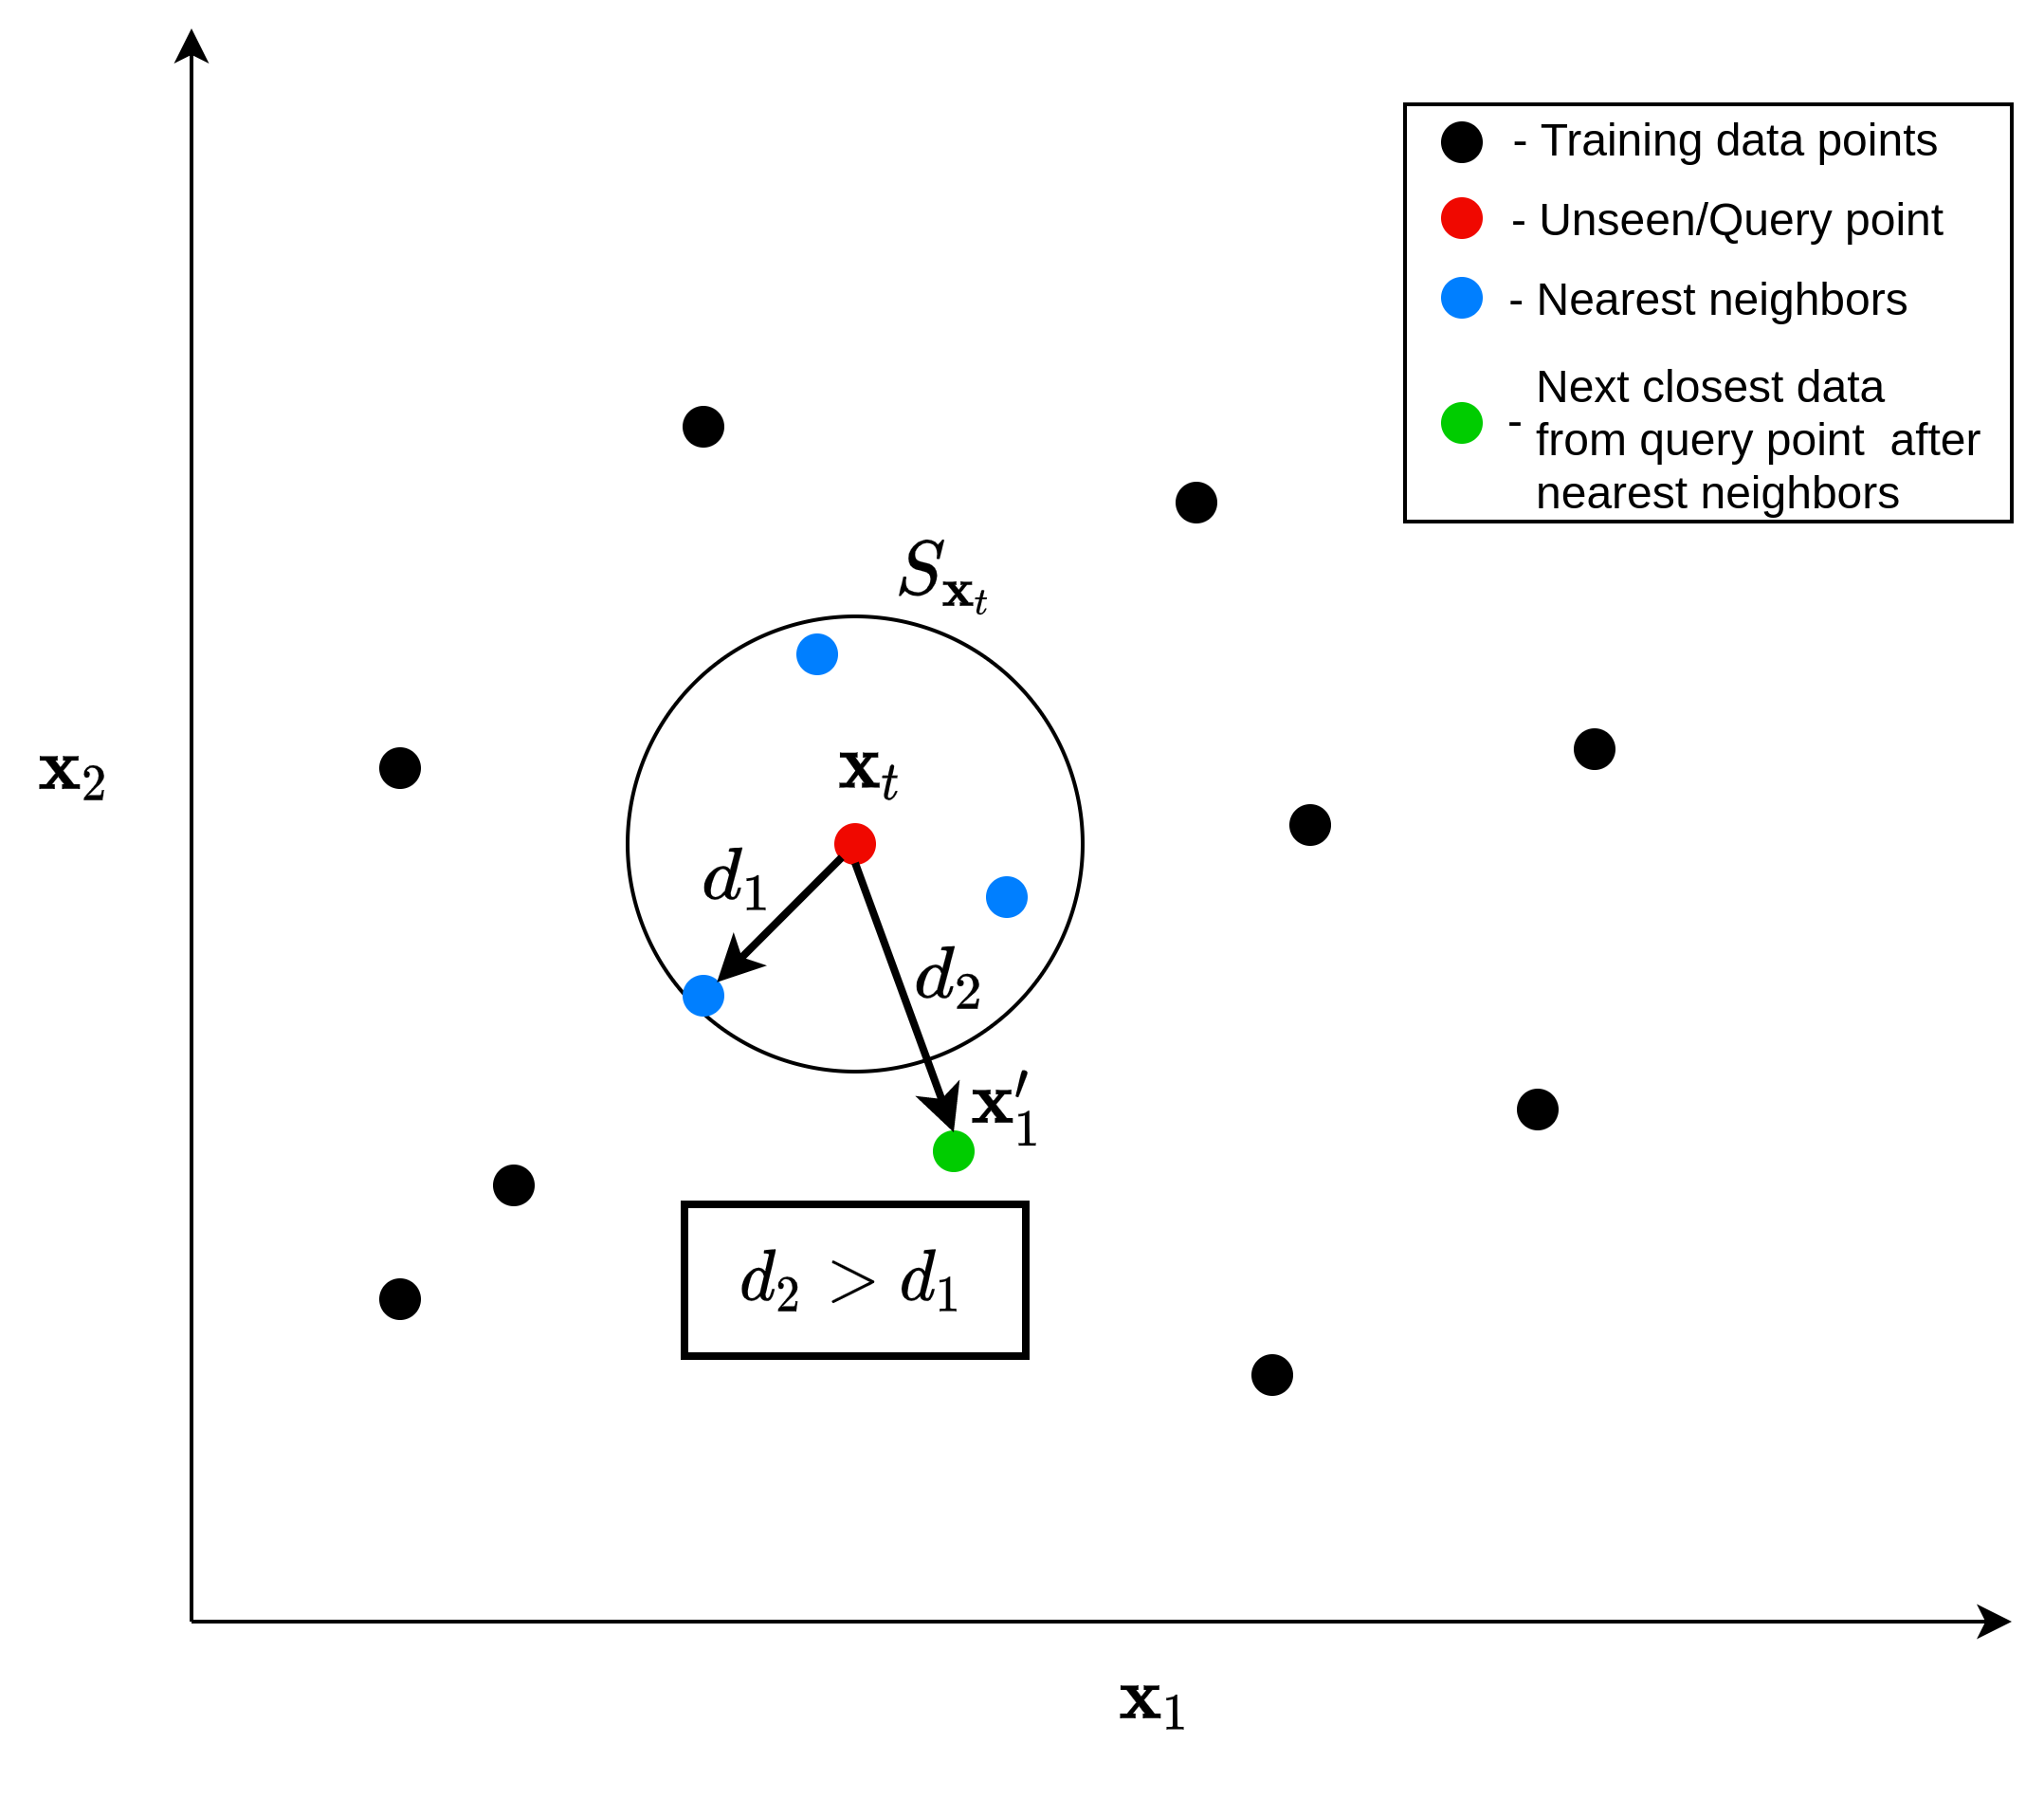   width=600"></p>


    <figcaption>Figure 1: Nearest neighbor set visualization</figcaption>
</center>
    Figure 1 shows the above mentioned properties of $S_{\mathbf{x}_t}$ on two-dimensional data set. Here, unseen data point($\mathbf{x}_t$) denoted by red circle. Applying 3-NN, the $S_{\mathbf{x}_t}$ computed is shown by black circle(with its element as blue dots) that has cardinality($\vert S_{\mathbf{x}_t}\vert$) equal to three($K$). Also, the maximum distance between query point and element of $S_{\mathbf{x}_t}$($d_1$) is less than distance between query point and next closest data point $\mathbf{x}'_1$($d_2$) which is not in $S_{\mathbf{x}_t}$. 

  2. Predict the target value of the test sample, $h(\mathbf{x}_t)$ as
highest count/frequency of class label in $S_{\mathbf{x}_t}$. Mathematically,  
    
    $$\boxed{h(\mathbf{x}_t) = \text{mode}(\{y'': (\mathbf{x}'',y'')\in S_{\mathbf{x}_t}\})}$$








<center>


<p><img src="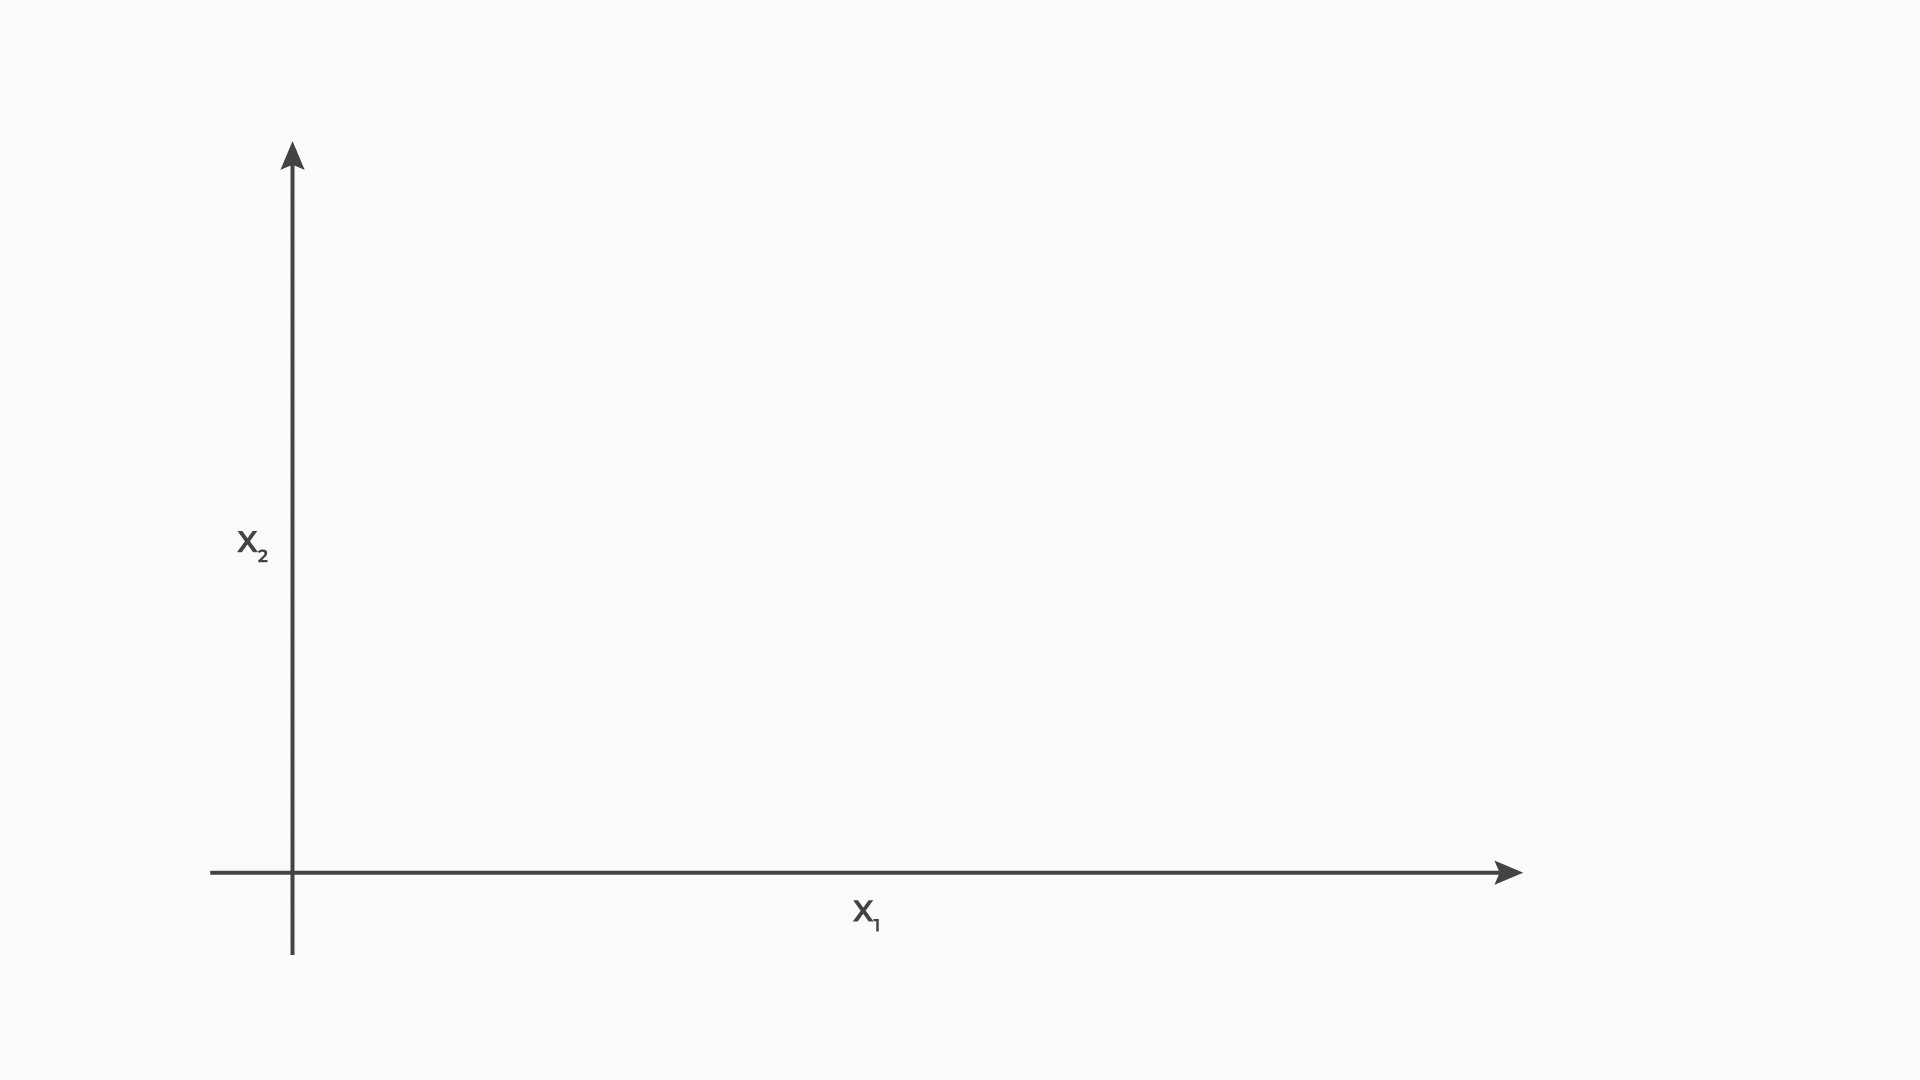   width=800"></p>


    <figcaption>Figure 2: Working of K-NN classifier in two dimensional multiclass classification scenario </figcaption>
</center>

Figure 1 shows an example of a K-NN classifier for two-dimensional feature space with three classes, where $K$ is set to 5. For the new test sample denoted by the blue cross, the 5-nearest neighbors are shown by arrows. Finally, using the majority vote scheme, the predicted label of the test sample is red-triangle class.


## Implementation of K-NN classifier

Now that you grasped the K-NN classifier's underlying concepts let's implement a K-NN classifier using the Numpy module. Using a functional paradigm for easier understanding, we must create functions required for implementing K-NN classifier, starting with the training function, ```train```.

Note: We will be using brute force and euclidean distance for computing nearest neighbors. Also, this implementation of the K-NN classifier only supports numerical data.

Numpy being the required module for implementation, should be imported at first.


In [ ]:
import numpy as np

### Training function

The training portion of the K-NN classifier simply requires the storage of training data or advanced data structure. As the brute force is the computation method, this implementation doesn't require computing any data structure. 


In [ ]:
def train(X_train, y_train):
    '''trains the K-NN classifier; i.e. storage of training data'''
    return 

As you can see, the ```train``` function doesn't require any statement and returns nothing. However, we can compute advanced data structures such as kd-tree in this step and store it. Next, let's develop functions for computing neighbors.


### Compute the distance between the new sample and stored samples

First, let's define function ```euclidean``` to compute the Euclidean distance between two data samples of shape ```(1,m)```.


In [ ]:
# Takes two samples x and y and computes the euclidean distance
euclidean = lambda x,y : np.sqrt(np.sum((x-y)**2)) 

Computing distance between the new data sample and all the stored training samples requires the application of loop. The ```calculate_distance``` function defined below computes the euclidean distance between a new sample and every stored training sample and returns the distance in list ```distances```.


In [ ]:
def calculate_distance(X_new, X_train):
    ''' Calculates distance between new sample and stored training samples'''
    
    distances = [] 
    
    for i in range(len(X_train)):
        distances.append(euclidean(X_new,X_train[i,:]))
    return distances

### Obtain labels of k-nearest neighbors

After the computation of distance metrics, the next step is finding the "K"-nearest neighbors and then obtain their respective target labels. Let's define a function named ```predict_labels``` that:

1. First, finds the index of "k"-nearest neighbors from the ```distances``` list computed from ```calculate_distance``` function.
    - Here, we use ```np.argsort``` to find the indices that would sort ```distances``` in ascending order, then take first k elements and store the index of ```near_neigh_index```.
    
    
2. Then, we compute the corresponding target values of the k-nearest neighbors of new sample, store in ```neigh_labels``` and return it.


In [ ]:
def predict_labels(y_train, distances, k):
    '''
    Return array of target values of k-nearest neighbors of a new sample
    
    Parameters
    ----------
    y_train: Numpy.array, shape(n,)
        training target vector
    distances: list,
            distance between new sample and stored samples
    k: int,
        number of neighbors to take into account
    
    Returns
    -------
    neigh_labels: Numpy.array, shape(k,)
                target labels of k-nearest neighbors
    
    '''
    
    near_neigh_index = np.argsort(distances)[:k] # Find indices of k nearest neighbors
    neigh_labels = y_train[near_neigh_index]  # labels of k nearest neighbors
    
    return neigh_labels

### Prediction from K-NN classifier

Finally, let's combine all the above-defined functions and implement K-NN classifier, ```knn_classifier```, which operates as:

1. Use ```train``` function to store the dataset. (Here, do nothing as we aren't computing any data structure.)
2. Initialize list ```predictions``` to store the predicted labels.
3. For each element of the set of new samples:
    1. Compute the distance between each stored sample using ```calculate_distance``` and store in ```neigh_dist```.
    2. Compute the labels of its k-nearest neighbors using ```predict_labels``` and store in ```k_labels```
    3. Use the voting scheme to compute its label and append to ```predictions``` list.
        Here, we are using ```np.bincount``` to count each label's occurrence and then find the maximum occurrence one using ```np.argmax```.
        
4. Return the ```predictions``` that are the prediction of K-NN classifier.


In [ ]:
def knn_classifier(X_train, y_train, X_test, k):
    '''K-NN classifier : Trains and then predicts label of test set
    
    Parameters
    ----------
    X_train: Numpy.array, shape(n,m)
        training feature vector
    y_train: Numpy.array, shape(n,)
        training target vector
    X_test: Numpy.array, shape(z,m)
        Data to be classified
    k: int
        Number of neighbors to take into account
    
    Returns
    -------
    predictions: Numpy.array, shape(z,)
        predicted labels of X_test
    '''
    
    train(X_train, y_train) # Training phase
    
    predictions = []
    
    for i in range(len(X_test)): # Prediction phase
        neigh_dist = calculate_distance(X_test[i,:], X_train)
        k_labels = predict_labels(y_train, neigh_dist, k)
        predictions.append(np.argmax(np.bincount(k_labels)))
        
    return np.array(predictions)

That's all for the implementation of the K-NN classifier. Note: Brute-force implementation of K-NN has time complexity $\approx \text{O(knm)}$, where n - number of training samples, m - dimension of features, k - number of voters.

Now, let's test the performance of this classifier in the ```iris``` dataset.  


### Loading Iris dataset with train-test split

We are using Scikit-learn for loading the dataset and train-test split.


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X_iris, y_iris = load_iris(return_X_y = True) # Loading the iris dataset

X_train, X_test, y_train, y_test = train_test_split(X_iris,  # Train-test split
                                                    y_iris,
                                                    test_size=0.3)

### Performance of K-NN classifier

Let's set the value of "K" at random to be 3, and then test the performance of the ```knn_classifier``` on both train and test set using Scikit-learn's ```classification_report```.


In [ ]:
# Predictions of training set
y_train_pred = knn_classifier(X_train, y_train, X_train, 3)

# Predictions of test set
y_test_pred = knn_classifier(X_train, y_train, X_test, 3)

In [ ]:
from sklearn.metrics import classification_report

# Performance evaluation
print('\t------------------training set------------------')
print(classification_report(y_train, y_train_pred))
print('\t--------------------test set--------------------')
print(classification_report(y_test, y_test_pred))

	------------------training set------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      0.94      0.95        33
           2       0.95      0.97      0.96        39

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105

	--------------------test set--------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      0.88      0.94        17
           2       0.85      1.00      0.92        11

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45



As seen, our implementation of the K-NN classifier performs exceptionally with 97% accuracy in the training set and 96% in the test set. That ends the portion on the implementation of the K-NN classifier. Now, let's visualization the decision boundary of the K-NN classifier for varying values of $K$.


## Decision-boundary of 1-NN classifier

Starting with smallest value of $K$, i.e. $K$=1, the prediction of new sample only depends upon its closest neighbor. Using this knowledge, the potential decision boundaries of the 1-NN classifier can be visualized using [**Voronoi diagram**]( https://en.wikipedia.org/wiki/Voronoi_diagram). Voronoi diagram shows the region of points that are closest to a given set of points. For an arbitary synthetic data with two classes(red and blue), the decision boundary using 1-NN classifier is:

<center>


<p><img src="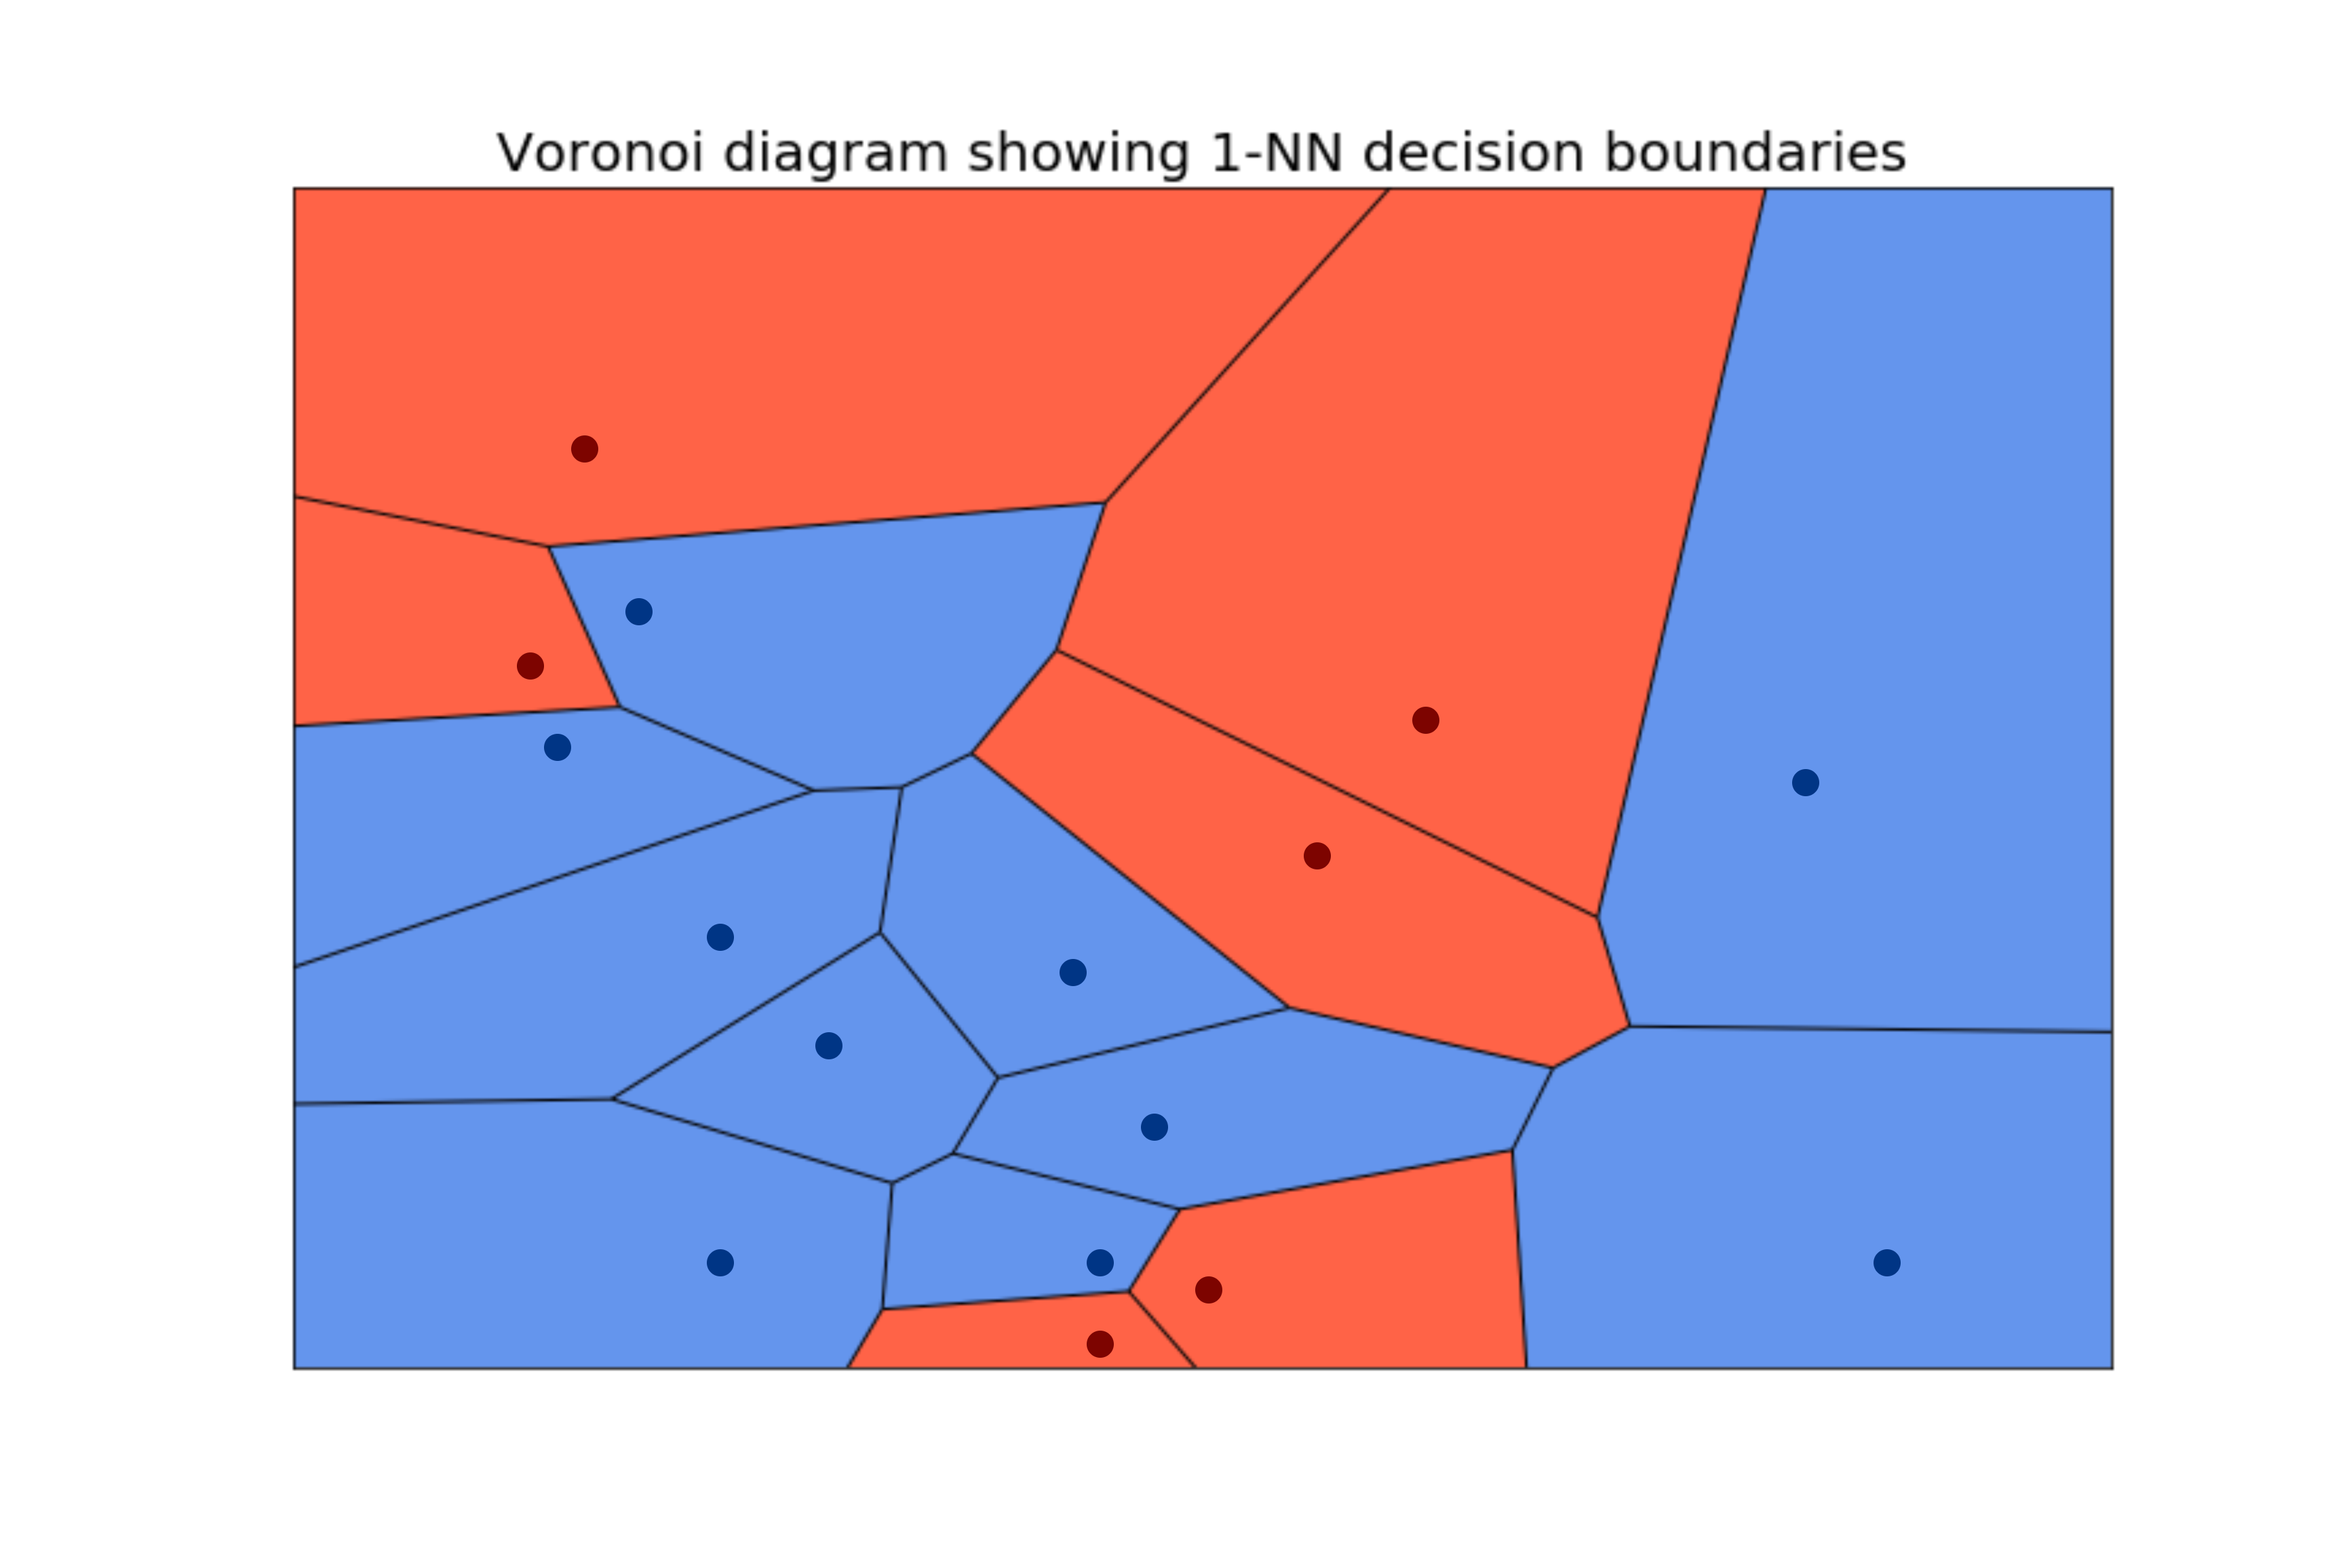   width=800"></p>


    <figcaption>Figure 3: Voronoi diagram showing potential decision boundary of 1-NN classifier using Euclidean distance metric</figcaption>
</center>

The region belonging to each point is colored according to their respective class. A new sample situated top-left would be classified as a red class in the above figure. Else if situated at bottom-right, would be classified as a blue class.


## Effect of K in K-NN classifier

Let's understand the *effect of the number of voters* from a simple example. During an election for president of a club(name not important) with 1000 people, we are assigned to figure out the percentage of people who will vote for representative A out of two representatives(A and B).

A simple solution is to randomly choose 40 club members from a particular age group, say 20-30, query each one on who they are planning to vote. Say the result comes out as:


<center>Table 1: Sample survey result on voting</center>

| Vote for A | Vote for B | Unsure(No response) | Total sample |
|-|-|-|-|
| 16 | 8 | 16 | 40 |

From this result, we can estimate the percentage of voting for representative A would be nearly equal to $$\frac{16}{16+8}*100= 66.67\%$$

However, the actual results came to be representative B, winning by 70% majority. How is this possible? There are many faults in the survey we conducted that introduced bias and variance:

- _Source of bias_

 - Using club members of a particular age group.
 - Not following up on the unsure members.

- _Source of variance_
 - Small sample size from the population.


Similarly, this idea extends to the number of voters in the K-NN classifier. Let's take a two-dimensional synthetic dataset with three classes, created using Scikit learn's ```make_classification``` method for visualization of decision boundaries.

<center>


<p><img src="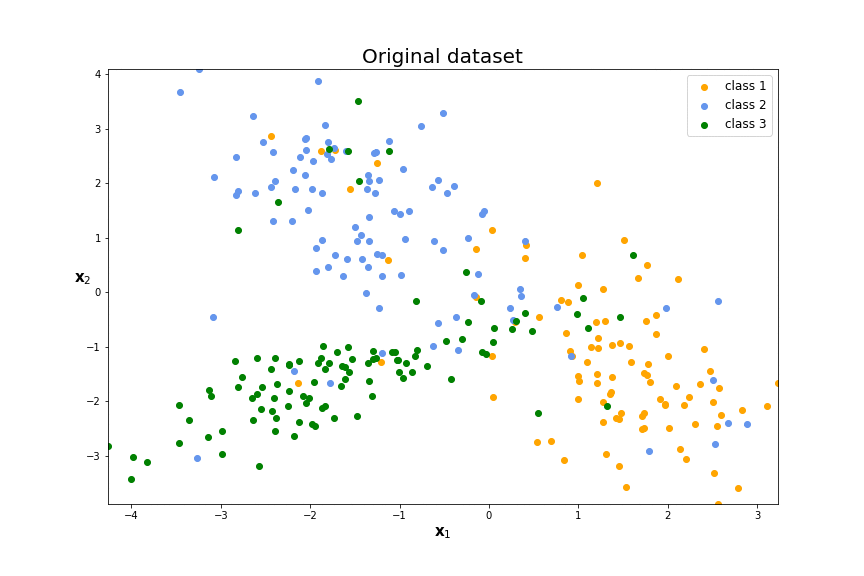   width=800"></p>


    <figcaption>Figure 4: Effect of K value in decision boundary of K-NN classifier</figcaption>
</center>

As seen in figure 3, the dataset is noisy. Applying the K-NN algorithm starting with $K=1$, the decision boundary is flexible/jagged, capturing almost every training datapoint's true label.  Due to a small number of voters, **small values of $K$ provide a more flexible fit, i.e., creates high variance and low bias classifier**. In contrast, a Higher $K$ value results in less flexible the decision boundary, producing an almost linear decision boundary at $K=100$. So,  **large values of $K$ creates low variance and high bias classifier**, the reason being a large number of voters tends to mask the actual structure of original mapping function $f(\mathbf{x})$.

In machine learning, finding the balance between bias and variance results in failure or success of the model's generalization power. Ergo, tuning the hyperparameter $K$ of K-NN classifier and setting the best value is a must. We will learn how to find the best value of $K$ in this unit's programming material.



## Application of K-NN classifier

Though generally slower and less accurate than Neural networks for larger data size, K-NN performs well with non-linear data and is desirable when having less knowledge regarding the dataset. let's discuss a few application areas of K-NN classifiers:

1.  **Image/ Video/ Text classification** . However, this requires preprocessing, such as dimensionality reduction and feature extraction.

   - For example, [HertaSecurity]( https://www.hertasecurity.com/en) uses K-NN to identify a person's face. Firstly, this system uses the DL algorithm to extract feature vectors from faces and later uses K-NN on those feature vectors for classification.
    
    
2. **K-NN search** - task related to finding similar items. A few examples of K-NN search are:

   - **Concept search**, finding semantically similar documents. Examples are finding novels with similar emotions.
   - **Recommender systems**, recommending users similar items that they prefer.
   
   
3. **Outlier detection**, using the notion of distance/neighborhoods to detect outliers.
    
    - Dang, T. T., et al. (2015) demonstrate the use of distance-based K-NN for outlier detection in large-scale traffic data in their [paper]( https://ieeexplore.ieee.org/document/7251924).


That's all for this read on K-NN classifiers. Next, we are discussing the K-NN model for the regression task, its comparison with linear regression models, the pros/cons of K-NN.



## Key-Takeaways

The main points to remember from this notebook are:

1. KNN-classifier, a lazy algorithm used for classification that works by:
    - Storing the training set ($D$) or data structure representing the training set.
    - Classifying new sample ($\mathbf{x}_t$) by, computing the "$K$" nearest neighbors ($S_{\mathbf{x}_t}$) among stored training set then, predicting the class of new sample ($h(\mathbf{x}_t)$) by **majority vote**.
    
    $$\boxed{h(\mathbf{x}_t) = \text{mode}(\{y'': (\mathbf{x}'',y'')\in S_{\mathbf{x}_t}\})}$$
    
2.  K-NN classifier slower than other model-based algorithms for a dataset containing large amounts of samples/features. It requires finding similarity of a new sample with all stored training samples, computational complexity $\approx \text{O(knm)}$.


3. Hyperparameter $K$ affects the K-NN model's decision boundaries as:
    - **Jagged and non-linear for lower values** of $K$, i.e., high variance and low bias.
    - **Smooth and linear for higher values** of $K$, i.e., high bias and low variance.


4. K-NN models have industrial applications such as image/video classification, K-NN search(recommender systems), and outlier detection.


## References

- Books
 1. James, G., Witten, D., Hastie, T., and Tibshirani, R. (2013), An introduction to statistical learning, Chapter 2 - Statistical learning, pg 39-41
 
- Lecture Notes
 1. Weinberger, K. (2018), Lecture 3-k-nearest neighbors, Retreived from Cornell University, CS4780 https://www.cs.cornell.edu/courses/cs4780/2018fa/
 
- Articles
 1. Fortmann-Roe, S. (2012), Understanding the bias-variance tradeoff
     - Topic 2-3, Understand bias-variance tradeoff intuitively for changes in voters $K$.


## Additional Materials

1. Fortmann-Roe, S. (2012), "[Understanding the bias-variance tradeoff]( http://scott.fortmann-roe.com/docs/BiasVariance.html)"
     - Try figure 5, change the values of $K$ using slidersand see how the decision boundary changes. 
     
2. [Stanfords CS231n, KNN]( https://cs231n.github.io/classification/#nn). 
